# Decision trees and interpretations with Python

In [1]:
# Loading data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [2]:
# Consstruct dataframe from X,y
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns in the dataframe
df = pd.DataFrame(X)
df['y'] = y
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


# Data analysis and Visualization

In [3]:
df['conversion'] = df['y'].map({'no': 0, 'yes': 1})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y,conversion
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no,0


In [4]:
conversion_rate_df = pd.DataFrame(df.groupby('conversion')['y'].count() / df.shape[0] * 100.0)
conversion_rate_df

,y
conversion,
0,88.30152
1,11.69848


In [5]:
conversion_rate_df.T

conversion,0,1
y,88.30152,11.69848


In [6]:
conversion_rate_by_job_df = df.groupby(by='job')['conversion'].sum() / df.groupby(by='job')['conversion'].count() * 100.0
conversion_rate_by_job_df

job
admin.           12.202669
blue-collar       7.274969
entrepreneur      8.271688
housemaid         8.790323
management       13.755551
retired          22.791519
self-employed    11.842939
services          8.883004
student          28.678038
technician       11.056996
unemployed       15.502686
Name: conversion, dtype: float64

In [7]:
import plotly.express as px

plot_df = conversion_rate_by_job_df.reset_index()

fig = px.bar(
    plot_df,
    x='conversion',
    y='job',
    orientation='h',
    title='Conversion Rates by Job',
    color_discrete_sequence=['skyblue'],
    template='ggplot2'
)

fig.update_layout(
    xaxis_title='conversion rate (%)',
    yaxis_title='Job'
)
fig.update_xaxes(showgrid=True)

fig.show()

# Default rates by conversions

In [8]:
default_by_conversion_df = pd.pivot_table(df, values='y', index='default', columns='conversion', aggfunc=len)
default_by_conversion_df

conversion,0,1
default,,
no,39159,5237
yes,763,52


In [9]:
import plotly.express as px
import plotly.colors as colors
plot_df = default_by_conversion_df.reset_index().melt(
    id_vars='default',
    var_name='conversion',
    value_name='count'
)

fig = px.pie(
    plot_df,
    names='default',
    values='count',
    facet_col='conversion',
    title='Default Rates by Conversion',
    template='ggplot2',
    color_discrete_sequence=colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label')
fig.show()

# Bank balances by conversions

In [10]:
plot_df = df[['conversion', 'balance']].copy()
plot_df['conversion'] = plot_df['conversion'].astype(str)

fig = px.box(
    plot_df,
    x='conversion',
    y='balance',
    points='outliers',
    title='Average Bank Balance Distributions by Conversion',
    template='ggplot2',
    color='conversion'
)

fig.update_layout(
    xaxis_title='Conversion',
    yaxis_title='Average Bank Balance',
    showlegend=False
)

fig.show()


In [11]:
plot_df = df[['conversion', 'balance']].copy()
plot_df['conversion'] = plot_df['conversion'].astype(str)

fig = px.box(
    plot_df,
    x='conversion',
    y='balance',
    points=False,
    title='Average Bank Balance Distributions by Conversion',
    template='ggplot2',
    color='conversion'
)

fig.update_layout(
    xaxis_title='Conversion',
    yaxis_title='Average Bank Balance',
    showlegend=False
)

fig.show()


# Conversion rates by number of contacts

In [12]:
conversions_by_num_contacts = (
	df.groupby(by='campaign')['conversion'].sum()
	/ df.groupby(by='campaign')['conversion'].count()
	* 100.0
)
conversions_by_num_contacts


campaign
1     14.597583
2     11.203519
3     11.193624
4      9.000568
5      7.879819
6      7.126259
7      6.394558
8      5.925926
9      6.422018
10     5.263158
11     7.960199
12     2.580645
13     4.511278
14     4.301075
15     4.761905
16     2.531646
17     8.695652
18     0.000000
19     0.000000
20     2.325581
21     2.857143
22     0.000000
23     0.000000
24     5.000000
25     0.000000
26     0.000000
27     0.000000
28     0.000000
29     6.250000
30     0.000000
31     0.000000
32    11.111111
33     0.000000
34     0.000000
35     0.000000
36     0.000000
37     0.000000
38     0.000000
39     0.000000
41     0.000000
43     0.000000
44     0.000000
46     0.000000
50     0.000000
51     0.000000
55     0.000000
58     0.000000
63     0.000000
Name: conversion, dtype: float64

In [13]:
pd.DataFrame(conversions_by_num_contacts)

,conversion
campaign,
1,14.597583
2,11.203519
3,11.193624
4,9.000568
5,7.879819
6,7.126259
7,6.394558
8,5.925926
9,6.422018


In [14]:
plot_df = conversions_by_num_contacts.reset_index()
plot_df.columns = ['campaign', 'conversion_rate']

fig = px.bar(
    plot_df,
    x='campaign',
    y='conversion_rate',
    title='Conversion Rates by Number of Contacts',
    template='ggplot2',
    color_discrete_sequence=['skyblue']
)

fig.update_layout(
    xaxis_title='Number of Contacts',
    yaxis_title='Conversion Rate (%)'
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)

fig.show()

# Encoding categorical variables for modeling

In [15]:
df['month'].unique()

<StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

In [16]:
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = df['month'].apply(lambda x: months.index(x)+1)
df['month'].unique()

array([ 5,  6,  7,  8, 10, 11, 12,  1,  2,  3,  4,  9])

In [17]:
df.groupby(by='month')['conversion'].count()

month
1      1403
2      2649
3       477
4      2932
5     13766
6      5341
7      6895
8      6247
9       579
10      738
11     3970
12      214
Name: conversion, dtype: int64

In [18]:
df['job'].unique()

<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
             nan,       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

In [19]:
jobs_encoded_df = pd.get_dummies(df['job'])
jobs_encoded_df.columns = ['job_%s' % x for x in jobs_encoded_df.columns]
jobs_encoded_df


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False
2,False,False,True,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
45206,False,False,False,False,False,False,False,False,False,True,False
45207,False,False,False,False,False,True,False,False,False,False,False
45208,False,False,False,False,False,True,False,False,False,False,False
45209,False,True,False,False,False,False,False,False,False,False,False


In [20]:
df = pd.concat([df, jobs_encoded_df], axis=1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y,conversion,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,5,261,1,-1,0,NaN,no,0,False,False,False,False,True,False,False,False,False,False,False
1,44,technician,single,secondary,no,29,yes,no,NaN,5,5,151,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,True,False
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,5,76,1,-1,0,NaN,no,0,False,False,True,False,False,False,False,False,False,False,False
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,5,92,1,-1,0,NaN,no,0,False,True,False,False,False,False,False,False,False,False,False
4,33,NaN,single,NaN,no,1,no,no,NaN,5,5,198,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,False,False


In [21]:
# Encoding marital status
marital_encoded_df = pd.get_dummies(df['marital'])
marital_encoded_df.columns = ['marital_%s' % x for x in marital_encoded_df.columns]
marital_encoded_df.head()

,marital_divorced,marital_married,marital_single
0,False,True,False
1,False,False,True
2,False,True,False
3,False,True,False
4,False,False,True


In [22]:
df = pd.concat([df, marital_encoded_df], axis=1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y,conversion,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,5,261,1,-1,0,NaN,no,0,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,44,technician,single,secondary,no,29,yes,no,NaN,5,5,151,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,5,76,1,-1,0,NaN,no,0,False,False,True,False,False,False,False,False,False,False,False,False,True,False
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,5,92,1,-1,0,NaN,no,0,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,33,NaN,single,NaN,no,1,no,no,NaN,5,5,198,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [23]:
# Enccoding Housing and Loan variables
df['housing'] = df['housing'].map({'no': 0, 'yes': 1})
df['loan'] = df['loan'].map({'no': 0, 'yes': 1})
df.head() 

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y,conversion,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,management,married,tertiary,no,2143,1,0,NaN,5,5,261,1,-1,0,NaN,no,0,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,44,technician,single,secondary,no,29,1,0,NaN,5,5,151,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,33,entrepreneur,married,secondary,no,2,1,1,NaN,5,5,76,1,-1,0,NaN,no,0,False,False,True,False,False,False,False,False,False,False,False,False,True,False
3,47,blue-collar,married,NaN,no,1506,1,0,NaN,5,5,92,1,-1,0,NaN,no,0,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,33,NaN,single,NaN,no,1,0,0,NaN,5,5,198,1,-1,0,NaN,no,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True


# Building a decision tree model

In [24]:
# Create feature list
features = [
    'age',
    'balance',
    'campaign',
    'previous',
    'housing',
] + list(jobs_encoded_df.columns) + list(marital_encoded_df.columns)

response_var = 'conversion'

In [25]:
features

['age',
 'balance',
 'campaign',
 'previous',
 'housing',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'marital_divorced',
 'marital_married',
 'marital_single']

In [26]:
from sklearn import tree

dt_model = tree.DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(df[features], df[response_var])


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [27]:
dt_model.classes_

array([0, 1])

# Interpreting the decision tree model

In [28]:
import graphviz
dot_data = tree.export_graphviz(
    dt_model,
    out_file=None,
    feature_names=features,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")

'decision_tree.pdf'

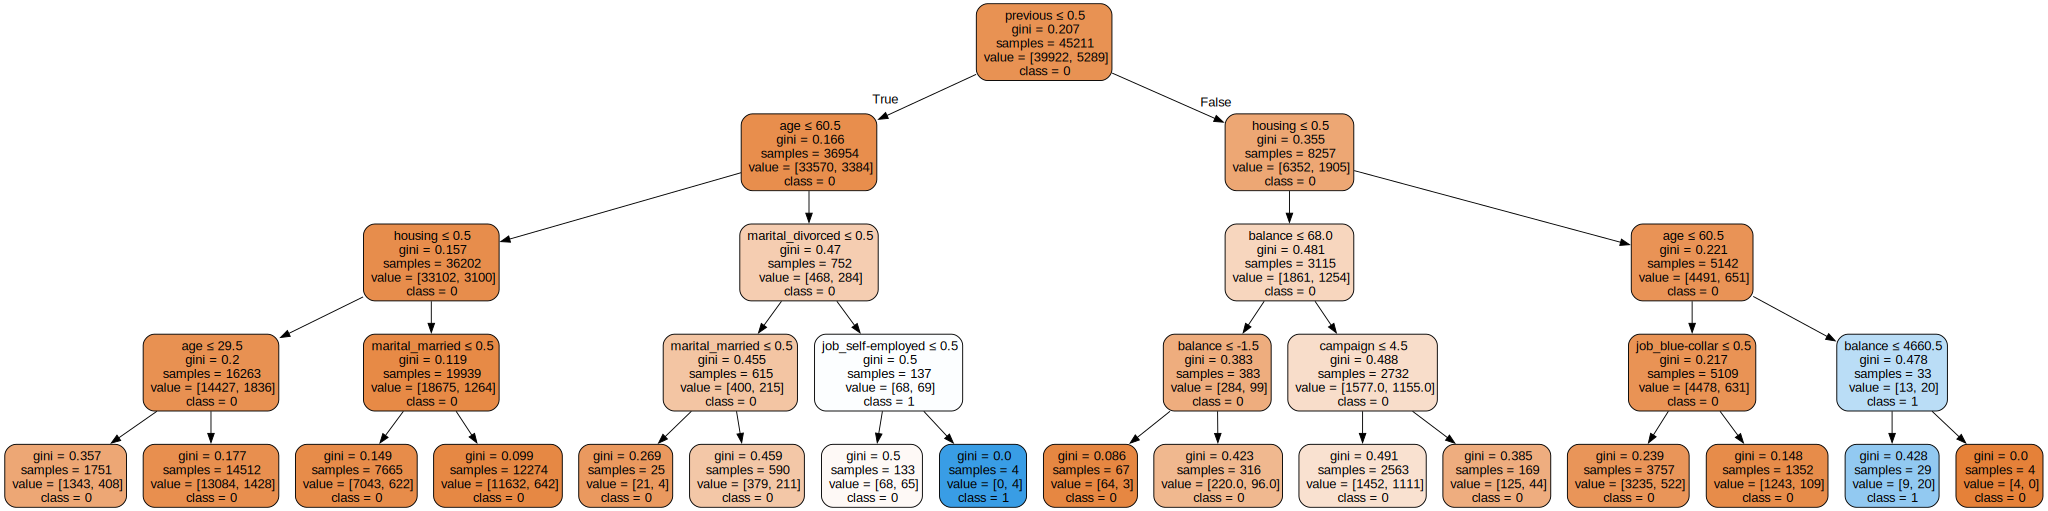

In [29]:
from IPython.display import display, HTML
display(HTML("<style>text {font-size: 10px;}</style>"))

graph